In [1]:
import torch 
import matplotlib.pyplot as plt
import numpy as np
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from matplotlib import cm
from supervised_learning_lqr import NetDGM 

In [3]:
#另一种网络构建方式，使用nn.ModuleList来构建隐藏层
class Net(nn.Module):
    # n_layer: the number of hidden layers
    # n_hidden: the number of vertices in each layer
    def __init__(self, n_layer, n_hidden, dim):
        super(Net, self).__init__()
        self.dim = dim
        self.input_layer = nn.Linear(dim, n_hidden)
        self.hidden_layers = nn.ModuleList([nn.Linear(n_hidden, n_hidden) for i in range(n_layer)])
        self.output_layer = nn.Linear(n_hidden, 1)
        
    def forward(self, x):
        o = self.act(self.input_layer(x))

        for i, li in enumerate(self.hidden_layers):
            o = self.act(li(o))
        
        out = self.output_layer(o)
        
        return out

    def act(self, x):
        return x * torch.sigmoid(x)
        # return torch.sigmoid(x)
         #return torch.tanh(x)
        # return torch.relu(x)

In [4]:
#config
from dataclasses import dataclass

@dataclass
class ProblemConfig:
    T: float = 1.0
    x_low: float = -3.0
    x_high: float = 3.0

In [5]:
# sampling functions
def sample_interior_points(batch_size, config, device):
    t = torch.rand(batch_size, 1, device=device) * config.T
    x = config.x_low + (config.x_high - config.x_low) * torch.rand(batch_size, 2, device=device)
    return t, x

def sample_terminal_points(batch_size, config, device):
    t = torch.full((batch_size, 1), config.T, device=device)
    x = config.x_low + (config.x_high - config.x_low) * torch.rand(batch_size, 2, device=device)
    return t, x

In [6]:
class LinearPDE2D:
    def __init__(self, model, H, M, C, D, R, sigma, config, device):
        """
        model: neural network, called as model(inp), inp shape = (N,3)
        H, M, C, D, R, sigma: torch tensors
        config: ProblemConfig
        device: 'cpu' or 'cuda'
        """
        self.model = model
        self.H = H.to(device).float()
        self.M = M.to(device).float()
        self.C = C.to(device).float()
        self.D = D.to(device).float()
        self.R = R.to(device).float()
        self.sigma = sigma.to(device).float()

        self.config = config
        self.T = float(config.T)
        self.device = device
        self.x_low = config.x_low
        self.x_high = config.x_high

        # alpha = (1,1)^T
        self.alpha = torch.tensor([1.0, 1.0], device=device).float()

        # Sigma = sigma sigma^T
        self.Sigma = self.sigma @ self.sigma.T   # (2,2)

    def terminal_target(self, x):
        # x^T R x
        Rx = x @ self.R.T
        return torch.sum(x * Rx, dim=1, keepdim=True)

    def pde_residual(self, t, x):
        """
        t: (N,1)
        x: (N,2)
        returns residual: (N,1)
        """
        t = t.clone().detach().requires_grad_(True)
        x = x.clone().detach().requires_grad_(True)

        inp = torch.cat([t, x], dim=1)   # (N,3)
        u = self.model(inp)              # (N,1)

        # u_t
        u_t = torch.autograd.grad(
            outputs=u,
            inputs=t,
            grad_outputs=torch.ones_like(u),
            create_graph=True,
            retain_graph=True
        )[0]

        # grad_x u = [u_x1, u_x2]
        u_x = torch.autograd.grad(
            outputs=u,
            inputs=x,
            grad_outputs=torch.ones_like(u),
            create_graph=True,
            retain_graph=True
        )[0]   # (N,2)

        ux1 = u_x[:, 0:1]
        ux2 = u_x[:, 1:2]

        # second derivatives
        u_xx1 = torch.autograd.grad(
            outputs=ux1,
            inputs=x,
            grad_outputs=torch.ones_like(ux1),
            create_graph=True,
            retain_graph=True
        )[0]   # (N,2)

        u_xx2 = torch.autograd.grad(
            outputs=ux2,
            inputs=x,
            grad_outputs=torch.ones_like(ux2),
            create_graph=True,
            retain_graph=True
        )[0]   # (N,2)

        u_xx_11 = u_xx1[:, 0:1]
        u_xx_12 = u_xx1[:, 1:2]
        u_xx_21 = u_xx2[:, 0:1]
        u_xx_22 = u_xx2[:, 1:2]

        # diffusion term: 0.5 * tr((sigma sigma^T) Hessian)
        diffusion = 0.5 * (
            self.Sigma[0, 0] * u_xx_11 +
            self.Sigma[0, 1] * u_xx_12 +
            self.Sigma[1, 0] * u_xx_21 +
            self.Sigma[1, 1] * u_xx_22
        )

        # (grad u)^T Hx
        Hx = x @ self.H.T
        drift1 = torch.sum(u_x * Hx, dim=1, keepdim=True)

        # (grad u)^T M alpha
        Malpha = (self.M @ self.alpha).view(1, 2).repeat(x.shape[0], 1)
        drift2 = torch.sum(u_x * Malpha, dim=1, keepdim=True)

        # x^T C x
        Cx = x @ self.C.T
        quad_x = torch.sum(x * Cx, dim=1, keepdim=True)

        # alpha^T D alpha
        alphaDa = (
            self.alpha.view(1, 2) @ self.D @ self.alpha.view(2, 1)
        ).view(1, 1).repeat(x.shape[0], 1)

        # PDE residual
        residual = u_t + diffusion + drift1 + drift2 + quad_x + alphaDa
        return residual

    def interior_loss(self, batch_size):
        t, x = sample_interior_points(batch_size, self.config, self.device)
        res = self.pde_residual(t, x)
        return torch.mean(res ** 2)

    def boundary_loss(self, batch_size):
        tT, x = sample_terminal_points(batch_size, self.config, self.device)
        inp = torch.cat([tT, x], dim=1)
        uT = self.model(inp)
        target = self.terminal_target(x)
        return torch.mean((uT - target) ** 2)

    def total_loss(self, batch_size, lambda_boundary=1.0):
        loss_interior = self.interior_loss(batch_size)
        loss_boundary = self.boundary_loss(batch_size)
        loss = loss_interior + lambda_boundary * loss_boundary
        return loss, loss_interior.detach(), loss_boundary.detach()

In [7]:
def mc_value_constant_control(x0, t0, T, H, M, C, D, R, sigma, alpha, n_steps=1000, n_mc=10000, seed=12345):
    """
    Monte Carlo estimate of the linear PDE solution under fixed control alpha.

    x0: tensor shape (1,2)
    t0: float
    T: float
    H, M, C, D, R, sigma: torch tensors on same device
    alpha: tensor shape (2,)
    """
    torch.manual_seed(seed)

    device = x0.device
    dt = (T - t0) / n_steps
    sqrt_dt = dt ** 0.5

    # Repeat initial state across MC paths
    X = x0.repeat(n_mc, 1)                     # (n_mc, 2)
    alpha_row = alpha.view(1, 2).repeat(n_mc, 1)

    running_cost = torch.zeros(n_mc, 1, device=device)

    for _ in range(n_steps):
        # running cost = x^T C x + alpha^T D alpha
        state_cost = torch.sum((X @ C) * X, dim=1, keepdim=True)
        control_cost = torch.sum((alpha_row @ D) * alpha_row, dim=1, keepdim=True)
        running_cost += (state_cost + control_cost) * dt

        # Euler step
        dW = sqrt_dt * torch.randn(n_mc, 2, device=device)
        drift = X @ H.T + alpha_row @ M.T
        X = X + drift * dt + dW @ sigma.T

    terminal_cost = torch.sum((X @ R) * X, dim=1, keepdim=True)
    total_cost = running_cost + terminal_cost

    return total_cost.mean().item()

In [8]:
test_points = [
    (0.0, 0.0, 0.0),
    (0.0, 1.0, 1.0),
    (0.2, 1.0, -1.0),
    (0.5, 2.0, 0.5),
]

In [9]:
@torch.no_grad()
def evaluate_against_mc(model, test_points, T, H, M, C, D, R, sigma, alpha, device,
                        n_steps=1000, n_mc=5000):
    """
    Return mean absolute error over a list of fixed test points.
    """
    model.eval()

    abs_errors = []
    records = []

    for (t0, x1, x2) in test_points:
        inp = torch.tensor([[t0, x1, x2]], dtype=torch.float32, device=device)
        pred = model(inp).item()

        x0 = torch.tensor([[x1, x2]], dtype=torch.float32, device=device)
        mc_val = mc_value_constant_control(
            x0=x0,
            t0=t0,
            T=T,
            H=H,
            M=M,
            C=C,
            D=D,
            R=R,
            sigma=sigma,
            alpha=alpha,
            n_steps=n_steps,
            n_mc=n_mc,
        )

        err = abs(pred - mc_val)
        abs_errors.append(err)

        records.append({
            "t": t0,
            "x1": x1,
            "x2": x2,
            "nn_value": pred,
            "mc_value": mc_val,
            "abs_error": err,
        })

    mean_abs_error = float(np.mean(abs_errors))
    return mean_abs_error, records

In [10]:
class Train():
    def __init__(self, net, pde_model, BATCH_SIZE, device):
        self.errors = []
        self.pde_errors = []
        self.bc_errors = []

        self.mc_errors = []
        self.mc_check_steps = []

        self.BATCH_SIZE = BATCH_SIZE
        self.net = net
        self.model = pde_model
        self.device = device

    def train(self, epoch, lr, print_every=100, mc_every=200,
            test_points=None, mc_n_steps=1000, mc_n_paths=5000,
            lambda_boundary=1.0):

        optimizer = optim.Adam(self.net.parameters(), lr=lr)
        avg_loss = 0.0

        # ===== 新增：记录最佳模型 =====
        best_mc_error = float("inf")
        best_state_dict = None

        for e in range(1, epoch + 1):
            self.net.train()
            optimizer.zero_grad()

            loss, loss_interior, loss_boundary = self.model.total_loss(
                self.BATCH_SIZE,
                lambda_boundary=lambda_boundary
            )

            avg_loss += float(loss.item())
            loss.backward()
            optimizer.step()

            # record
            self.errors.append(loss.item())
            self.pde_errors.append(loss_interior.item())
            self.bc_errors.append(loss_boundary.item())

            # print
            if e % print_every == 0:
                mean_loss = avg_loss / print_every
                print(f"Epoch {e} - lr {lr} - total loss: {mean_loss:.6f} "
                    f"- pde loss: {loss_interior.item():.6f} "
                    f"- terminal loss: {loss_boundary.item():.6f}")
                avg_loss = 0.0

            # ===== MC evaluation =====
            if (test_points is not None) and (e % mc_every == 0):

                mean_mc_error, records = evaluate_against_mc(
                    model=self.net,
                    test_points=test_points,
                    T=self.model.T,
                    H=self.model.H,
                    M=self.model.M,
                    C=self.model.C,
                    D=self.model.D,
                    R=self.model.R,
                    sigma=self.model.sigma,
                    alpha=self.model.alpha,
                    device=self.device,
                    n_steps=mc_n_steps,
                    n_mc=mc_n_paths
                )

                self.mc_errors.append(mean_mc_error)
                self.mc_check_steps.append(e)

                print(f"           MC mean abs error = {mean_mc_error:.6e}")

                for rec in records:
                    print(rec)

                # ===== ⭐关键新增：保存最佳模型 =====
                if mean_mc_error < best_mc_error:
                    best_mc_error = mean_mc_error
                    best_state_dict = {
                        k: v.detach().cpu().clone()
                        for k, v in self.net.state_dict().items()
                    }

        # ===== ⭐训练结束恢复最佳模型 =====
        if best_state_dict is not None:
            self.net.load_state_dict(best_state_dict)
            self.net.to(self.device)
            print(f"\nLoaded best model with MC error = {best_mc_error:.6e}")

    def get_errors(self):
        return self.errors

    def get_mc_errors(self):
        return self.mc_check_steps, self.mc_errors

    def save_model(self):
        torch.save(self.net.state_dict(), 'net_model.pth')

    def plot_kpi(self):
        plt.figure()
        plt.plot(self.errors, '-b', label='Total Loss')
        plt.plot(self.pde_errors, '-r', label='PDE Loss')
        plt.plot(self.bc_errors, '-g', label='Terminal Loss')
        plt.yscale('log')
        plt.xlabel('Training Step')
        plt.ylabel('Loss')
        plt.title('Training Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def plot_mc_error(self):
        plt.figure()
        plt.plot(self.mc_check_steps, self.mc_errors, '-o', label='MC Error')
        plt.yscale('log')
        plt.xlabel('Training Step')
        plt.ylabel('Mean Absolute Error vs Monte Carlo')
        plt.title('DGM Error against Monte Carlo Solution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

In [11]:
class Demo():
    def __init__(self, net, pde_model, nx1, nx2, device):
        self.net = net
        self.pde_model = pde_model
        self.nx1 = nx1
        self.nx2 = nx2
        self.device = device

        self.x1_range = np.linspace(pde_model.x_low, pde_model.x_high, nx1)
        self.x2_range = np.linspace(pde_model.x_low, pde_model.x_high, nx2)

    def get_solution_slice(self, t_value=0.0):
        self.est_solution = np.zeros((self.nx1, self.nx2))

        for i, x1 in enumerate(self.x1_range):
            for j, x2 in enumerate(self.x2_range):
                inp = torch.tensor([[t_value, x1, x2]], dtype=torch.float32, device=self.device)
                with torch.no_grad():
                    val = self.net(inp).cpu().numpy().item()
                self.est_solution[i, j] = val

        return self.est_solution

    def plot_surface(self, t_value=0.0):
        Z = self.get_solution_slice(t_value=t_value)
        X1, X2 = np.meshgrid(self.x1_range, self.x2_range, indexing='ij')

        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(X1, X2, Z, cmap=cm.RdYlBu_r, edgecolor='blue',
                        linewidth=0.0003, antialiased=True)
        ax.set_title(f"NN approximation of u(t, x1, x2) at t={t_value}")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_zlabel("u")
        plt.show()

    def compare_with_mc(self, test_points, n_steps=1000, n_mc=5000):
        """
        test_points: list of tuples [(t, x1, x2), ...]
        returns list of dictionaries with NN prediction, MC estimate, abs error
        """
        results = []

        for (t, x1, x2) in test_points:
            inp = torch.tensor([[t, x1, x2]], dtype=torch.float32, device=self.device)
            with torch.no_grad():
                pred = self.net(inp).item()

            x0 = torch.tensor([[x1, x2]], dtype=torch.float32, device=self.device)

            mc = mc_value_constant_control(
                x0=x0,
                t0=t,
                T=self.pde_model.T,
                H=self.pde_model.H,
                M=self.pde_model.M,
                C=self.pde_model.C,
                D=self.pde_model.D,
                R=self.pde_model.R,
                sigma=self.pde_model.sigma,
                alpha=self.pde_model.alpha,
                n_steps=n_steps,
                n_mc=n_mc
            )

            if isinstance(mc, torch.Tensor):
                mc = mc.item()

            results.append({
                "t": t,
                "x1": x1,
                "x2": x2,
                "nn_value": pred,
                "mc_value": mc,
                "abs_error": abs(pred - mc)
            })

        return results


NetDGM(
  (input_layer): Linear(in_features=3, out_features=100, bias=True)
  (dgm_layers): ModuleList(
    (0-2): 3 x DGMLayer(
      (Uz): Linear(in_features=3, out_features=100, bias=True)
      (Wz): Linear(in_features=100, out_features=100, bias=True)
      (Ug): Linear(in_features=3, out_features=100, bias=True)
      (Wg): Linear(in_features=100, out_features=100, bias=True)
      (Ur): Linear(in_features=3, out_features=100, bias=True)
      (Wr): Linear(in_features=100, out_features=100, bias=True)
      (Uh): Linear(in_features=3, out_features=100, bias=True)
      (Wh): Linear(in_features=100, out_features=100, bias=True)
    )
  )
  (output_layer): Linear(in_features=100, out_features=1, bias=True)
)
Epoch 100 - lr 0.001 - total loss: 16.369041 - pde loss: 0.058689 - terminal loss: 0.088127
           MC mean abs error = 2.710708e-01
{'t': 0.0, 'x1': 0.0, 'x2': 0.0, 'nn_value': 4.8983869552612305, 'mc_value': 5.403921127319336, 'abs_error': 0.5055341720581055}
{'t': 0.0, 'x

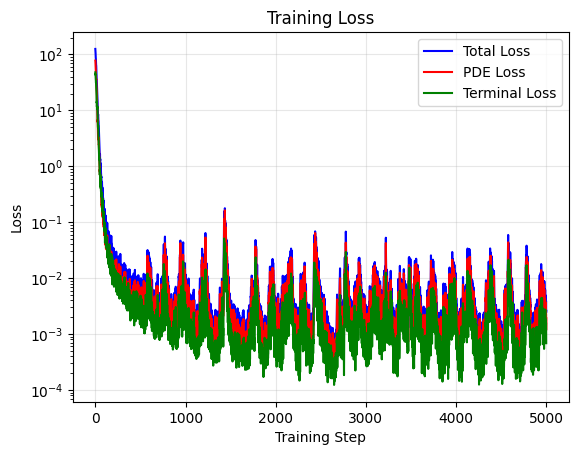

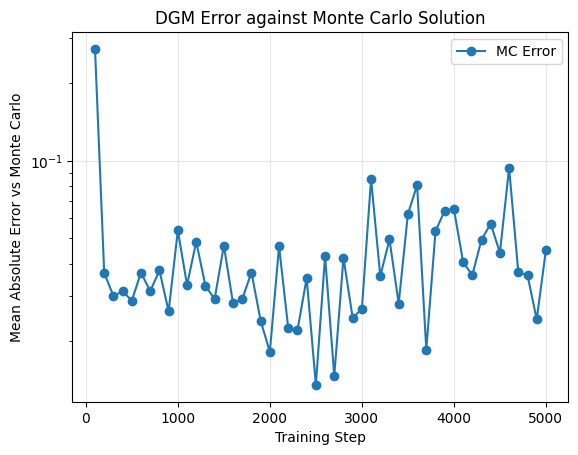

In [19]:
# ===== define matrices from Exercise 1.1 =====
H = torch.tensor([[0.1, 0.0],
                  [0.0, 0.2]], dtype=torch.float32)

M = torch.eye(2, dtype=torch.float32)

C = torch.eye(2, dtype=torch.float32)

D = torch.eye(2, dtype=torch.float32)

R = torch.eye(2, dtype=torch.float32)

sigma = 0.3 * torch.eye(2, dtype=torch.float32)


device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. network
#net = Net(n_layer=3, n_hidden=25, dim=3).to(device)
from supervised_learning_lqr import NetDGM 

net = NetDGM(input_dim=3, hidden_dim=100, num_layers=3, output_dim=1).to(device)
print(net)

# 2. terminal time
T = 1.0

# 3. PDE model
config = ProblemConfig(T=1.0, x_low=-3.0, x_high=3.0)

pde_model = LinearPDE2D(
    model=net,
    H=H,
    M=M,
    C=C,
    D=D,
    R=R,
    sigma=sigma,
    config=config,
    device=device
)

# 4. trainer
train = Train(net, pde_model, BATCH_SIZE=2**10, device=device)

train.train(
    epoch=5000,
    lr=0.001,
    print_every=100,
    mc_every=100,
    test_points=test_points,
    mc_n_steps=1000,
    mc_n_paths=5000,
    lambda_boundary=1.0
)

# 6. plot training loss
train.plot_kpi()

# ⭐ 新增：MC误差曲线（第四条核心）
train.plot_mc_error()

# 7. demo / visualization
demo = Demo(net, pde_model, nx1=80, nx2=80, device=device)

In [20]:
# ===== define matrices from Exercise 1.1 =====
H = torch.tensor([[0.1, 0.0],
                  [0.0, 0.2]], dtype=torch.float32)

M = torch.eye(2, dtype=torch.float32)

C = torch.eye(2, dtype=torch.float32)

D = torch.eye(2, dtype=torch.float32)

R = torch.eye(2, dtype=torch.float32)

sigma = 0.3 * torch.eye(2, dtype=torch.float32)


device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# Section 4 / Exercise 4.1
# Policy Iteration with DGM
# Cell 1: setup and hyperparameters
# =========================


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- problem setting ----
T = 1.0

# state sampling region
x_low, x_high = -3.0, 3.0

# batch sizes
BATCH_INTERIOR = 128
BATCH_TERMINAL = 128
BATCH_HAMILTONIAN = 128

# ---- network sizes ----
VALUE_HIDDEN_DIM = 100
POLICY_HIDDEN_DIM = 100

# ---- training schedule ----
N_POLICY_ITER = 3
VALUE_EPOCHS_PER_ITER = 400
POLICY_EPOCHS_PER_ITER = 200

LR_VALUE = 1e-3
LR_POLICY = 1e-3

LAMBDA_TERMINAL = 1.0

# ---- evaluation ----
N_TEST = 1000

# ---- sanity check on matrices from previous sections ----
# 假设你前面已经定义好了 H, M, C, D, R, sigma
# 这里把它们统一放到 device 上，并转成 float32 tensor
H = H.to(device).float()
M = M.to(device).float()
C = C.to(device).float()
D = D.to(device).float()
R = R.to(device).float()
sigma = sigma.to(device).float()

print("H shape:", H.shape)
print("M shape:", M.shape)
print("C shape:", C.shape)
print("D shape:", D.shape)
print("R shape:", R.shape)
print("sigma shape:", sigma.shape)

# ---- histories ----
value_loss_history_all = []
value_interior_history_all = []
value_terminal_history_all = []

policy_loss_history_all = []

outer_iter_value_error = []
outer_iter_policy_error = []

Using device: cpu
H shape: torch.Size([2, 2])
M shape: torch.Size([2, 2])
C shape: torch.Size([2, 2])
D shape: torch.Size([2, 2])
R shape: torch.Size([2, 2])
sigma shape: torch.Size([2, 2])


In [21]:
# =========================
# Cell 2: policy network
# =========================

class PolicyNet(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=100, output_dim=2):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, t, x):
        """
        t: shape (batch, 1) or (batch,)
        x: shape (batch, 2)

        return:
            a: shape (batch, 2)
        """
        if t.dim() == 1:
            t = t.unsqueeze(1)
        
        inp = torch.cat([t, x], dim=1)   # shape: (batch, 3)
        a = self.net(inp)                # shape: (batch, 2)
        return a


# instantiate policy network
policy_net = PolicyNet(
    input_dim=3,
    hidden_dim=POLICY_HIDDEN_DIM,
    output_dim=2
).to(device)

print(policy_net)

# quick shape test
t_test = torch.rand(5, 1, device=device)
x_test = torch.rand(5, 2, device=device)

a_test = policy_net(t_test, x_test)
print("a_test shape:", a_test.shape)   # should be (5, 2)

PolicyNet(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=2, bias=True)
  )
)
a_test shape: torch.Size([5, 2])


In [22]:
# =========================
# Cell 3: PDE loss with policy network
# =========================

def sample_interior(batch_size, T, x_low, x_high, device):
    # Sample interior points (t, x)
    t = torch.rand(batch_size, 1, device=device) * T
    x = x_low + (x_high - x_low) * torch.rand(batch_size, 2, device=device)
    x.requires_grad_(True)
    t.requires_grad_(True)
    return t, x


def sample_terminal(batch_size, T, x_low, x_high, device):
    # Sample terminal points (t = T, x)
    t = torch.full((batch_size, 1), T, device=device)
    x = x_low + (x_high - x_low) * torch.rand(batch_size, 2, device=device)
    x.requires_grad_(True)
    t.requires_grad_(True)
    return t, x


def terminal_value(x, R):
    # Compute terminal condition: x^T R x
    Rx = x @ R.T
    return torch.sum(x * Rx, dim=1, keepdim=True)


def pde_loss_with_policy(value_net, policy_net,
                         batch_interior=BATCH_INTERIOR,
                         batch_terminal=BATCH_TERMINAL,
                         T=T, x_low=x_low, x_high=x_high,
                         lambda_terminal=LAMBDA_TERMINAL):
    """
    Compute total loss for value network using current policy network.

    Returns:
        total_loss, interior_loss, terminal_loss
    """

    # ---------- Interior loss ----------
    t, x = sample_interior(batch_interior, T, x_low, x_high, device)

    # Forward pass through value network
    inp = torch.cat([t, x], dim=1)
    u = value_net(inp)

    # First derivatives
    grad_u = torch.autograd.grad(
        u, [t, x],
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )

    u_t = grad_u[0]
    u_x = grad_u[1]

    # Second derivatives (Hessian)
    u_x1 = u_x[:, 0:1]
    u_x2 = u_x[:, 1:2]

    grad_u_x1 = torch.autograd.grad(
        u_x1, x,
        grad_outputs=torch.ones_like(u_x1),
        create_graph=True
    )[0]

    grad_u_x2 = torch.autograd.grad(
        u_x2, x,
        grad_outputs=torch.ones_like(u_x2),
        create_graph=True
    )[0]

    # Hessian components
    u_xx_11 = grad_u_x1[:, 0:1]
    u_xx_12 = grad_u_x1[:, 1:2]
    u_xx_21 = grad_u_x2[:, 0:1]
    u_xx_22 = grad_u_x2[:, 1:2]

    # Assemble Hessian matrix: (batch, 2, 2)
    Hessu = torch.stack([
        torch.cat([u_xx_11, u_xx_12], dim=1),
        torch.cat([u_xx_21, u_xx_22], dim=1)
    ], dim=1)

    # Policy output a(t,x)
    a = policy_net(t, x)

    # Compute PDE terms
    Hx = x @ H.T
    Ma = a @ M.T

    gradHx = torch.sum(u_x * Hx, dim=1, keepdim=True)
    gradMa = torch.sum(u_x * Ma, dim=1, keepdim=True)

    Cx = x @ C.T
    xCx = torch.sum(x * Cx, dim=1, keepdim=True)

    Da = a @ D.T
    aDa = torch.sum(a * Da, dim=1, keepdim=True)

    # Diffusion term: 1/2 * trace(sigma sigma^T Hessian)
    SigmaSigmaT = sigma @ sigma.T
    diff_term = 0.5 * torch.einsum('ij,bij->b', SigmaSigmaT, Hessu).unsqueeze(1)

    # PDE residual
    residual = u_t + diff_term + gradHx + gradMa + xCx + aDa
    interior_loss = torch.mean(residual ** 2)

    # ---------- Terminal loss ----------
    t_T, x_T = sample_terminal(batch_terminal, T, x_low, x_high, device)

    inp_T = torch.cat([t_T, x_T], dim=1)
    u_T = value_net(inp_T)

    target_T = terminal_value(x_T, R)
    terminal_loss = torch.mean((u_T - target_T) ** 2)

    # ---------- Total loss ----------
    total_loss = interior_loss + lambda_terminal * terminal_loss

    return total_loss, interior_loss, terminal_loss

In [23]:
# =========================
# Cell 4: Hamiltonian loss for policy update
# =========================

def hamiltonian_loss(value_net, policy_net,
                     batch_size=BATCH_HAMILTONIAN,
                     T=T, x_low=x_low, x_high=x_high):
    """
    Compute the Hamiltonian loss used to update the policy network.

    Returns:
        loss: scalar tensor
    """

    # Sample interior points
    t, x = sample_interior(batch_size, T, x_low, x_high, device)

    # Forward pass through value network
    inp = torch.cat([t, x], dim=1)
    v = value_net(inp)

    # Compute spatial gradient of value function
    grad_v = torch.autograd.grad(
        v, x,
        grad_outputs=torch.ones_like(v),
        create_graph=True
    )[0]

    # Forward pass through policy network
    a = policy_net(t, x)

    # Compute Hamiltonian terms
    Hx = x @ H.T
    Ma = a @ M.T

    gradHx = torch.sum(grad_v * Hx, dim=1, keepdim=True)
    gradMa = torch.sum(grad_v * Ma, dim=1, keepdim=True)

    Cx = x @ C.T
    xCx = torch.sum(x * Cx, dim=1, keepdim=True)

    Da = a @ D.T
    aDa = torch.sum(a * Da, dim=1, keepdim=True)

    # Hamiltonian
    ham = gradHx + gradMa + xCx + aDa

    # Minimize batch average of Hamiltonian
    loss = torch.mean(ham)

    return loss

In [24]:
# =========================
# Cell 5: train value network given current policy
# =========================

def train_value_net(value_net, policy_net,
                    epochs=VALUE_EPOCHS_PER_ITER,
                    lr=LR_VALUE,
                    batch_interior=BATCH_INTERIOR,
                    batch_terminal=BATCH_TERMINAL,
                    lambda_terminal=LAMBDA_TERMINAL,
                    print_every=200):
    """
    Train the value network while keeping the policy network fixed.

    Returns:
        value_net: trained value network
        history_total: list of total losses
        history_interior: list of interior losses
        history_terminal: list of terminal losses
    """

    optimizer = optim.Adam(value_net.parameters(), lr=lr)

    history_total = []
    history_interior = []
    history_terminal = []

    value_net.train()
    policy_net.eval()

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        total_loss, interior_loss, terminal_loss = pde_loss_with_policy(
            value_net=value_net,
            policy_net=policy_net,
            batch_interior=batch_interior,
            batch_terminal=batch_terminal,
            T=T,
            x_low=x_low,
            x_high=x_high,
            lambda_terminal=lambda_terminal
        )

        total_loss.backward()
        optimizer.step()

        history_total.append(total_loss.item())
        history_interior.append(interior_loss.item())
        history_terminal.append(terminal_loss.item())

        if epoch % print_every == 0:
            print(
                f"[Value Net] Epoch {epoch}/{epochs} | "
                f"Total: {total_loss.item():.6f} | "
                f"Interior: {interior_loss.item():.6f} | "
                f"Terminal: {terminal_loss.item():.6f}"
            )

    return value_net, history_total, history_interior, history_terminal

In [25]:
# =========================
# Cell 6: train policy network given current value
# =========================

def train_policy_net(value_net, policy_net,
                     epochs=POLICY_EPOCHS_PER_ITER,
                     lr=LR_POLICY,
                     batch_size=BATCH_HAMILTONIAN,
                     print_every=200):
    """
    Train the policy network while keeping the value network fixed.

    Returns:
        policy_net: trained policy network
        history_policy: list of Hamiltonian losses
    """

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)

    history_policy = []

    value_net.eval()
    policy_net.train()

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        loss = hamiltonian_loss(
            value_net=value_net,
            policy_net=policy_net,
            batch_size=batch_size,
            T=T,
            x_low=x_low,
            x_high=x_high
        )

        loss.backward()
        optimizer.step()

        history_policy.append(loss.item())

        if epoch % print_every == 0:
            print(
                f"[Policy Net] Epoch {epoch}/{epochs} | "
                f"Hamiltonian: {loss.item():.6f}"
            )

    return policy_net, history_policy

In [27]:
from exercise1_1 import LQRRiccatiSolver

solver = LQRRiccatiSolver(
    H.cpu().numpy(),
    M.cpu().numpy(),
    C.cpu().numpy(),
    D.cpu().numpy(),
    R.cpu().numpy(),
    sigma.cpu().numpy(),
    T
)
solver.solve_riccati(np.linspace(0.0, T, 5001))

In [28]:
# =========================
# Cell 7: outer policy iteration loop
# =========================

def evaluate_on_test_grid(value_net, policy_net, lqr_solver, n_test=N_TEST):
    value_net.eval()
    policy_net.eval()

    with torch.no_grad():
        t_test = torch.rand(n_test, 1, device=device) * T
        x_test = x_low + (x_high - x_low) * torch.rand(n_test, 2, device=device)

        v_pred = value_net(torch.cat([t_test, x_test], dim=1))
        a_pred = policy_net(t_test, x_test)

        x_test_lqr = x_test
        t_test_lqr = t_test.squeeze(1)

        v_true = lqr_solver.value_function(t_test_lqr, x_test_lqr)
        a_true = lqr_solver.markov_control(t_test_lqr, x_test_lqr)

        if v_true.dim() == 1:
            v_true = v_true.unsqueeze(1)

        if a_true.dim() == 3:
            a_true = a_true.squeeze(1)

        value_error = torch.mean(torch.abs(v_pred - v_true)).item()
        policy_error = torch.mean(torch.norm(a_pred - a_true, dim=1)).item()

    return value_error, policy_error


# Re-initialize networks before policy iteration
value_net = NetDGM(3, VALUE_HIDDEN_DIM).to(device)
policy_net = PolicyNet(
    input_dim=3,
    hidden_dim=POLICY_HIDDEN_DIM,
    output_dim=2
).to(device)

print("Starting policy iteration...")
print(value_net)
print(policy_net)

for k in range(1, N_POLICY_ITER + 1):
    print("\n" + "=" * 60)
    print(f"Policy Iteration Step {k}/{N_POLICY_ITER}")
    print("=" * 60)

    # ----- Step 1: train value network given current policy -----
    value_net, hist_total, hist_interior, hist_terminal = train_value_net(
        value_net=value_net,
        policy_net=policy_net,
        epochs=VALUE_EPOCHS_PER_ITER,
        lr=LR_VALUE,
        batch_interior=BATCH_INTERIOR,
        batch_terminal=BATCH_TERMINAL,
        lambda_terminal=LAMBDA_TERMINAL,
        print_every=200
    )

    value_loss_history_all.extend(hist_total)
    value_interior_history_all.extend(hist_interior)
    value_terminal_history_all.extend(hist_terminal)

    # ----- Step 2: train policy network given current value -----
    policy_net, hist_policy = train_policy_net(
        value_net=value_net,
        policy_net=policy_net,
        epochs=POLICY_EPOCHS_PER_ITER,
        lr=LR_POLICY,
        batch_size=BATCH_HAMILTONIAN,
        print_every=200
    )

    policy_loss_history_all.extend(hist_policy)

    # ----- Step 3: evaluate current approximation -----
    # Replace 'lqr' with your actual Exercise 1.1 solver object name
    value_err, policy_err = evaluate_on_test_grid(
        value_net=value_net,
        policy_net=policy_net,
        lqr_solver=solver,
        n_test=N_TEST
    )

    outer_iter_value_error.append(value_err)
    outer_iter_policy_error.append(policy_err)

    print(
        f"[Outer Iter {k}] "
        f"Mean value error: {value_err:.6f} | "
        f"Mean policy error: {policy_err:.6f}"
    )

Starting policy iteration...
NetDGM(
  (input_layer): Linear(in_features=3, out_features=100, bias=True)
  (dgm_layers): ModuleList(
    (0-2): 3 x DGMLayer(
      (Uz): Linear(in_features=3, out_features=100, bias=True)
      (Wz): Linear(in_features=100, out_features=100, bias=True)
      (Ug): Linear(in_features=3, out_features=100, bias=True)
      (Wg): Linear(in_features=100, out_features=100, bias=True)
      (Ur): Linear(in_features=3, out_features=100, bias=True)
      (Wr): Linear(in_features=100, out_features=100, bias=True)
      (Uh): Linear(in_features=3, out_features=100, bias=True)
      (Wh): Linear(in_features=100, out_features=100, bias=True)
    )
  )
  (output_layer): Linear(in_features=100, out_features=1, bias=True)
)
PolicyNet(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=2, bias=True)
  )

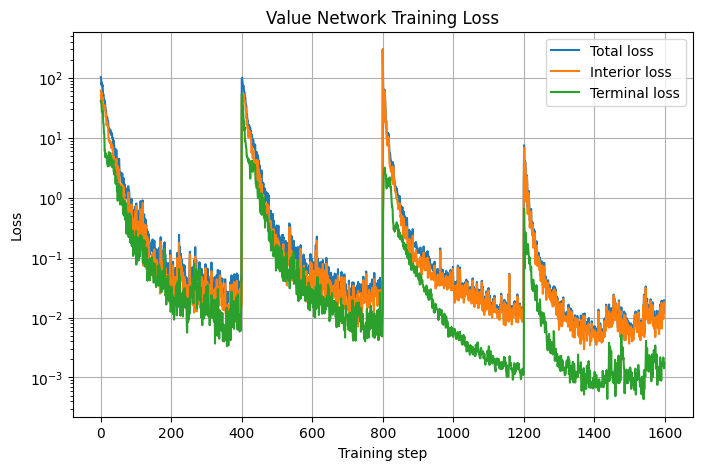

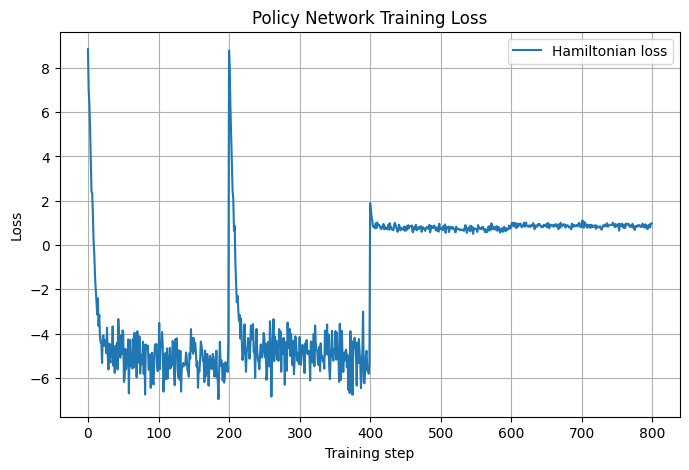

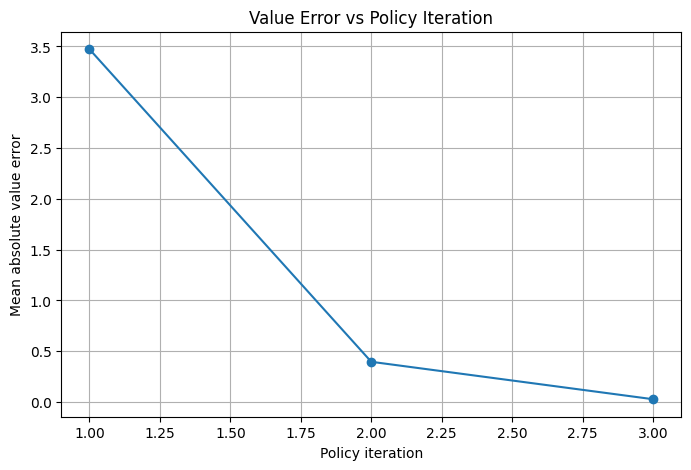

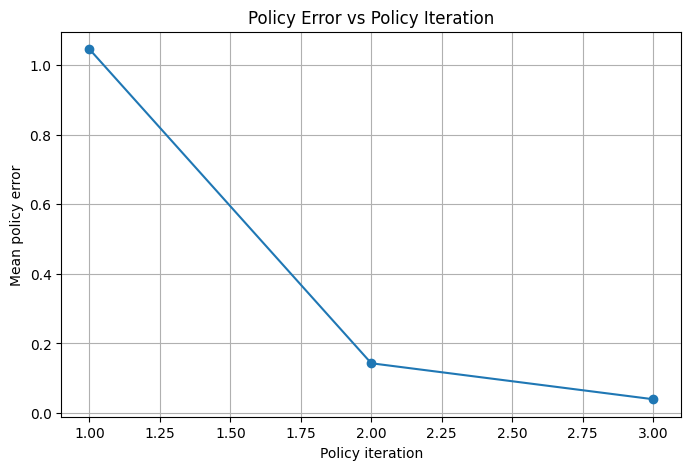

Final diagnostics
Final mean value error:  0.027526
Final mean policy error: 0.039862
Total value training steps:  1600
Total policy training steps: 800


In [29]:
# =========================
# Cell 8: plots and final diagnostics
# =========================

# Plot value network losses
plt.figure(figsize=(8, 5))
plt.plot(value_loss_history_all, label="Total loss")
plt.plot(value_interior_history_all, label="Interior loss")
plt.plot(value_terminal_history_all, label="Terminal loss")
plt.yscale("log")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Value Network Training Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot policy network loss
plt.figure(figsize=(8, 5))
plt.plot(policy_loss_history_all, label="Hamiltonian loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Policy Network Training Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot outer iteration value error
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(outer_iter_value_error) + 1), outer_iter_value_error, marker="o")
plt.xlabel("Policy iteration")
plt.ylabel("Mean absolute value error")
plt.title("Value Error vs Policy Iteration")
plt.grid(True)
plt.show()

# Plot outer iteration policy error
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(outer_iter_policy_error) + 1), outer_iter_policy_error, marker="o")
plt.xlabel("Policy iteration")
plt.ylabel("Mean policy error")
plt.title("Policy Error vs Policy Iteration")
plt.grid(True)
plt.show()

# Print final summary
print("=" * 60)
print("Final diagnostics")
print("=" * 60)

if len(outer_iter_value_error) > 0:
    print(f"Final mean value error:  {outer_iter_value_error[-1]:.6f}")

if len(outer_iter_policy_error) > 0:
    print(f"Final mean policy error: {outer_iter_policy_error[-1]:.6f}")

print(f"Total value training steps:  {len(value_loss_history_all)}")
print(f"Total policy training steps: {len(policy_loss_history_all)}")